## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Maya Yonathan

**Date:** 10/2/2026

Q1 - 1. Regression predicts a numerical value, while classification predicts a category or class. For example, predicting someone's blood pressure would be regression, while predicting whether someone has a disease would be classification.

Q1 - 2. A confusion table compares the actual class labels with the labels predicted by a classification model. It shows which classes were predicted correctly and which classes were confused with each other. This is useful because overall accuracy alone does not show what kinds of mistakes the model is making.

Q1 - 3. SSE, or sum of squared errors, measures how far the model's predictions are from the actual values. It adds up the squared differences between each prediction and its true value. A smaller SSE generally indicates that the predictions are closer to the observed data.

Q1 - 4. Overfitting happens when a model fits the training data too closely and learns noise or very specific patterns that do not generalize well to new data. Underfitting happens when a model is too simple and does not capture enough of the underlying pattern in the data.

Q1 - 5. A train/test split lets us build the model on one group of data and evaluate it on data it has not already seen. Testing different values of \(k\) helps us choose a model that performs better on new observations rather than just memorizing the training data. One caveat is that ideally you should not repeatedly tune parameters using the final test set, because that can make the reported test performance overly optimistic.

Q1 - 6. A class label is simple and easy to interpret because it gives one predicted category. The weakness is that it hides how uncertain the model is. A probability distribution gives more information by showing how strongly the model supports each class, which can be useful when the consequences of a mistake are important. The downside is that probabilities are more complicated to communicate and may not always be well calibrated.

In [1]:
!git clone https://github.com/sds3001/A03-knn.git
%cd A03-knn

Cloning into 'A03-knn'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 0), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 6.98 KiB | 1.16 MiB/s, done.
/content/A03-knn


In [2]:
import os

print(os.getcwd())
print(os.listdir())
print(os.listdir('./data'))

/content/A03-knn
['README.md', 'notebook.ipynb', '.git', 'data']
['land_mines.csv']


In [3]:
print(os.listdir('./data'))

['land_mines.csv']


In [4]:
import pandas as pd

mines = pd.read_csv('./data/land_mines.csv')

mines.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [5]:
print(mines.shape)
print(mines.columns.tolist())

(338, 4)
['voltage', 'height', 'soil', 'mine_type']


In [6]:
mines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


In [7]:
mines['mine_type'].value_counts().sort_index()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


In [8]:
mines['mine_type'].value_counts(
    normalize=True
).sort_index()

,proportion
mine_type,
1,0.210059
2,0.207101
3,0.195266
4,0.195266
5,0.192308


In [9]:
mines[
    ['voltage', 'height', 'soil']
].describe()

,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


In [10]:
mines.isna().sum()

,0
voltage,0
height,0
soil,0
mine_type,0


In [11]:
mines.groupby('mine_type')[
    ['voltage', 'height', 'soil']
].mean()

,voltage,height,soil
mine_type,,,
1,0.296463,0.495519,0.492958
2,0.721123,0.487013,0.508571
3,0.402408,0.527548,0.496970
4,0.345365,0.506887,0.503030
5,0.379598,0.530070,0.516923


In [12]:
from sklearn.model_selection import train_test_split

X = mines[['voltage', 'height', 'soil']]
y = mines['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

print("\nTraining class counts:")
print(y_train.value_counts().sort_index())

print("\nTest class counts:")
print(y_test.value_counts().sort_index())

Training size: 169
Test size: 169

Training class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Test class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

results = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    results.append({
        'k': k,
        'accuracy': accuracy
    })

results_df = pd.DataFrame(results)

results_df

,k,accuracy
0,1,0.508876
1,2,0.473373
2,3,0.408284
3,4,0.414201
4,5,0.420118
5,6,0.414201
6,7,0.402367
7,8,0.414201
8,9,0.431953
9,10,0.431953


In [15]:
best_row = results_df.loc[
    results_df['accuracy'].idxmax()
]

best_k = int(best_row['k'])
best_accuracy = best_row['accuracy']

print("Best k:", best_k)
print("Best accuracy:", best_accuracy)

Best k: 1
Best accuracy: 0.5088757396449705


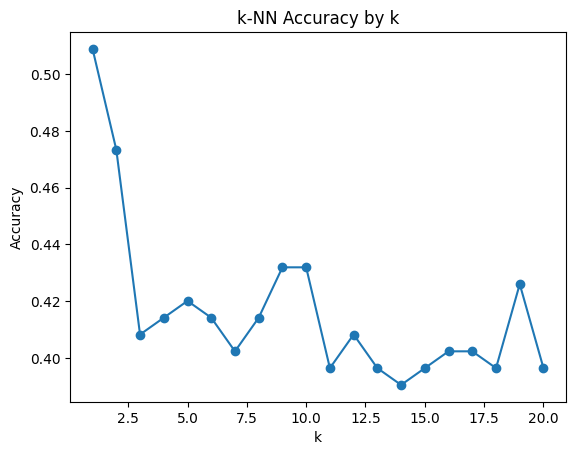

In [16]:
import matplotlib.pyplot as plt

plt.plot(
    results_df['k'],
    results_df['accuracy'],
    marker='o'
)

plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('k-NN Accuracy by k')
plt.show()

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

best_model = KNeighborsClassifier(n_neighbors=best_k)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

print("Final test accuracy:", accuracy_score(y_test, y_pred))

Final test accuracy: 0.5088757396449705


In [19]:
confusion = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

confusion

Predicted,1,2,3,4,5
Actual,,,,,
1,22,0,3,3,8
2,0,32,0,3,0
3,7,0,10,9,7
4,6,5,4,13,5
5,6,0,10,7,9


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           1       0.54      0.61      0.57        36
           2       0.86      0.91      0.89        35
           3       0.37      0.30      0.33        33
           4       0.37      0.39      0.38        33
           5       0.31      0.28      0.30        32

    accuracy                           0.51       169
   macro avg       0.49      0.50      0.49       169
weighted avg       0.50      0.51      0.50       169



I tested values of \(k\) from 1 through 20 and calculated the classification accuracy for each one. The highest accuracy occurred at \(k=1\), with an accuracy of about 50.9%, so I selected \(k=1\) for the final model.

The model performs much better for mine type 2 than the other classes. Mine type 2 has a recall of about 91%, meaning that 32 out of 35 actual type 2 mines were classified correctly. Mine type 1 also performs somewhat better, with 22 out of 36 classified correctly. The model has much more difficulty with mine types 3, 4, and 5. Their recall values are only about 30%, 39%, and 28%, respectively. For example, type 3 is often confused with types 1, 4, and 5, while type 5 is frequently classified as type 3 or 4. This shows that the overall accuracy of about 50.9% does not tell the full story because the model works much better for some classes than others.

I would not recommend using this model by itself to identify land mines in a real situation. Even though it performs very well for mine type 2, the overall accuracy is only about 51%, and the confusion table shows a lot of mistakes for types 3, 4, and 5. Since incorrectly identifying a land mine could have serious consequences, the model would be more useful as an extra tool to support trained personnel rather than making the final decision. Predictions involving the classes with lower accuracy should especially be verified using other information or methods.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [18]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]